# TimesNet encoder (self-supervised pretraining, encoder tasks S1.2.1 – S1.2.4, S1.2.6) — benign + GridSybil trial, T = 64

This notebook explains and checks the encoder of the adopted plan. The code itself lives in the package
`src/model/benign_gridsybil/timesnet/` (`encoder.py`, `config.py`); the notebook **imports** it and prints the source of
each class, so what you read here is exactly what pretraining runs. **Nothing is trained here** (forward passes only).

| Task   | What                                                                | Section           |
| ------ | ------------------------------------------------------------------- | ----------------- |
| S1.2.1 | Embedding: Conv1d token embedding + fixed positions, no time of day | Embedding         |
| S1.2.2 | Inception block + TimesBlock with per-window top-3 periods (f ≥ 2)  | TimesBlock        |
| S1.2.3 | TimesNet encoder: 4 blocks, LayerNorm, masked mean → (H, z)         | TimesNet encoder  |
| S1.2.4 | Checks                                                              | Checks            |
| S1.2.6 | Period diagnostic on train windows                                  | Period diagnostic |

**In and out.** One window = 64 messages × 13 features plus a mask (1 = real message, 0 = padding). The encoder
returns **H** (64 × d: one vector per message) and **z** (d: one vector per window), with **d = 128** and inner width
**d_ff = 64** (the professor's plan, D12). Self-supervised pretraining trains the encoder without attack labels;
few-shot fine-tuning later trains on few labels and scores windows from z. The encoder follows one rule: **padding
never changes the output.** (The Transformer ablation is no longer part of the code; the encoder is TimesNet only.)


## Setup

Imports, the repository root as working directory (so `src.…` imports work), the device (Apple GPU if available), a
fixed seed, and a small helper `show` that prints the source code of a class from the package.


In [1]:
import inspect
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

for folder in [Path.cwd(), *Path.cwd().parents]:  # notebooks live in src/<folder>/...; work from the repo root
    if (folder / "CLAUDE.md").is_file():
        os.chdir(folder)
        break
assert Path("CLAUDE.md").is_file() and Path("data").is_dir(), "run inside the repository"
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from src.model.benign_gridsybil.timesnet.config import PretrainConfig
from src.model.benign_gridsybil.timesnet.encoder import (
    InceptionBlock2d,
    MaskedOps,
    PeriodFinder,
    TimesBlock,
    TimesNetEncoder,
    TokenEmbedding,
)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
print("torch", torch.__version__, "| device", DEVICE, "| repo", Path.cwd())


def show(obj) -> None:
    """Print the source code of a class or function from the package."""
    display(Markdown(f"```python\n{inspect.getsource(obj).rstrip()}\n```"))

torch 2.14.1 | device mps | repo /Users/bibekgupta/Downloads/projects/sybil-llm


## Settings

All sizes come from `PretrainConfig` (the same settings object pretraining uses): **d = 128** and inner width
**d_ff = 64** (decision D12, 2026-10-08: the professor's plan; supersedes d = 512 of D11 and d_ff = d of D10) →
2,301,312 TimesNet parameters; 4 TimesBlocks, the 3
strongest periods per window, Inception kernels 1×1, 3×3, 5×5. Only the encoder fields are listed here.


In [2]:
CONFIG = PretrainConfig()
ENCODER_FIELDS = [
    "data_dir",
    "seq_len",
    "n_features",
    "d_model",
    "d_ff",
    "n_blocks",
    "top_k",
    "n_kernels",
    "min_freq",
    "dropout",
]
for name in ENCODER_FIELDS:
    print(f"{name:<11} {getattr(CONFIG, name)}")

data_dir    src/data/encoder_input/benign_gridsybil/T64
seq_len     64
n_features  13
d_model     128
d_ff        64
n_blocks    4
top_k       3
n_kernels   3
min_freq    2
dropout     0.1


## A batch of real windows

One training shard (10,000 windows) is enough to look at the encoder. Only the feature file is read
(`part-XXXXX.json`: id, x, mask); the `_info` files with labels are never opened. A batch is 256 windows:
`x` (256, 64, 13) and `mask` (256, 64).


In [3]:
def read_feature_shard(data_dir: str, split: str, index: int = 0) -> tuple[torch.Tensor, torch.Tensor]:
    """x and mask of one feature shard (never the label file)."""
    path = sorted((Path(data_dir) / split).glob("b*/part-?????.json"))[index]
    assert "_info" not in path.name
    windows = json.loads(path.read_text())["windows"]
    x = torch.tensor([w["x"] for w in windows], dtype=torch.float32)
    mask = torch.tensor([w["mask"] for w in windows], dtype=torch.bool)
    return x, mask


X_TRAIN, MASK_TRAIN = read_feature_shard(CONFIG.data_dir, "train", 0)
batch_x, batch_mask = X_TRAIN[:256], MASK_TRAIN[:256]
n_real = batch_mask.sum(1)
print("x", tuple(batch_x.shape), "| mask", tuple(batch_mask.shape))
print(
    f"real rows per window: min {int(n_real.min())}, median {int(n_real.median())}, max {int(n_real.max())}; "
    f"padding share {1 - batch_mask.float().mean():.1%}"
)

x (256, 64, 13) | mask (256, 64)
real rows per window: min 1, median 11, max 64; padding share 75.0%


## The mask rule

71% of all rows are padding. If the encoder treated those zeros as data, it would learn the window length instead of
the motion. `MaskedOps` holds the three operations that keep padding out: fill padding with 0, average over real
rows only, and an error that counts chosen rows only. Example: real rows [2, 4, 6] + two padding rows → plain mean
2.4, masked mean 4.0.


In [4]:
show(MaskedOps)
demo_h = torch.tensor([[[2.0], [4.0], [6.0], [0.0], [0.0]]])
demo_mask = torch.tensor([[True, True, True, False, False]])
print("plain mean", demo_h.mean(dim=1).item(), "| masked mean", MaskedOps.masked_mean(demo_h, demo_mask).item())

```python
class MaskedOps:
    """Mask-aware tensor operations; `mask` is (B, T) bool with True for real rows."""

    @staticmethod
    def fill_padding(x: torch.Tensor, mask: torch.Tensor, value: float = 0.0) -> torch.Tensor:
        """(B, T, C) -> same, every padding row set to `value`."""
        return x.masked_fill(~mask.bool().unsqueeze(-1), value)

    @staticmethod
    def masked_mean(h: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """Mean over the real rows of each window: (B, T, d) -> (B, d)."""
        mask = mask.bool()
        total = MaskedOps.fill_padding(h, mask).sum(dim=1)
        count = mask.sum(dim=1, keepdim=True).clamp(min=1).to(h.dtype)
        return total / count

    @staticmethod
    def masked_mse(pred: torch.Tensor, target: torch.Tensor, rows: torch.Tensor) -> torch.Tensor:
        """Mean squared error over the selected rows (B, T) and all features -> scalar."""
        rows = rows.bool()
        squared = MaskedOps.fill_padding((pred - target) ** 2, rows).sum(dim=-1)
        return squared.sum() / (rows.sum().clamp(min=1).to(pred.dtype) * pred.shape[-1])
```

plain mean 2.4000000953674316 | masked mean 4.0


## Embedding (S1.2.1)

**What:** turn each message's 13 numbers into d = 128 numbers (the model width), like a token embedding in a
Transformer. There is no vocabulary (the inputs are continuous), so it is a learned linear map.

**How:** a `Conv1d(13 → 128, kernel 3)` slides along time. For message t it computes
`e_t = W₋₁·x(t−1) + W₀·x(t) + W₊₁·x(t+1)` (each W is 128 × 13), so every vector already sees one neighbour on each
side (a little local motion). Then a fixed sine/cosine position table (not learned) is added, and the mask sets
padding rows back to 0.

**Choices:** zero padding at the edges (TimesNet's default circular padding would wrap the last rows — padding — into
the first one); no time-of-day embedding (time of day alone separates the two scenario groups, a leak).

Shapes: `(B, 64, 13) → transpose (B, 13, 64) → conv (B, 128, 64) → transpose (B, 64, 128)`; 128 × 13 × 3 = 4,992
weights.


In [5]:
show(TokenEmbedding)
with torch.no_grad():
    demo_e = TokenEmbedding(CONFIG).eval()(batch_x, batch_mask)
print(
    "embedding:",
    tuple(batch_x.shape),
    "->",
    tuple(demo_e.shape),
    "| padding rows are 0:",
    bool((demo_e[~batch_mask] == 0).all()),
)

```python
class TokenEmbedding(nn.Module):
    """Conv1d over time (zero padding) + fixed sin/cos positions + dropout; padding rows set to 0."""

    def __init__(self, settings: PretrainConfig, max_len: int = 512) -> None:
        super().__init__()
        self.conv = nn.Conv1d(
            settings.n_features, settings.d_model, kernel_size=3, padding=1, padding_mode="zeros", bias=False
        )
        nn.init.kaiming_normal_(self.conv.weight, mode="fan_in", nonlinearity="leaky_relu")
        self.dropout = nn.Dropout(settings.dropout)
        position = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, settings.d_model, 2).float() * (-math.log(10000.0) / settings.d_model))
        table = torch.zeros(max_len, settings.d_model)
        table[:, 0::2] = torch.sin(position * div_term)
        table[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("positions", table, persistent=False)  # fixed, not a parameter

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """(B, T, 13) -> (B, T, d), padding rows 0."""
        tokens = self.conv(x.transpose(1, 2)).transpose(1, 2)  # (B, d, T) -> (B, T, d)
        out = self.dropout(tokens + self.positions[: x.shape[1]])
        return out * mask.unsqueeze(-1).to(out.dtype)
```

embedding: (256, 64, 13) -> (256, 64, 128) | padding rows are 0: True


## TimesBlock (S1.2.2)

A TimesBlock is TimesNet's replacement for attention. Four ideas, in order:

1. **Find rhythms** (`PeriodFinder`). An FFT over each window's **real rows only** gives the strength of every
   frequency; skip f = 0 (the mean) and f = 1 (the whole window), keep the 3 strongest. Period = real rows ÷ f.
   Example: 28 real rows, strongest f = 2, 4, 5 → periods 14, 7, 5. Fewer than 4 real rows → no rhythm → period 1.
2. **Fold.** For each period p, pad 64 rows up to a multiple of p and reshape the sequence into a grid:
   rows = cycles, columns = position inside a cycle. p = 14: 64 → 70 rows → 5 × 14.
3. **Convolve in 2-D** (`InceptionBlock2d`). 1×1, 3×3 and 5×5 convolutions run side by side and are averaged.
   On the grid, left/right = neighbouring messages, up/down = the same moment one cycle earlier/later. Two blocks:
   128 → 64 → GELU → 128 channels (bottleneck d_ff = 64, D12; p = 14: (128, 5, 14) → (64, 5, 14) → (128, 5, 14)).
   The bottleneck halves the convolution weights compared with d_ff = 128 (2.30M vs 4.60M parameters), which suits
   ~5.7k sender vehicles and trains faster; d_ff = 128 is the first ablation if the model underfits.
4. **Unfold and mix.** Back to 64 × 128, mix the 3 period branches with softmax of their FFT strengths, add the
   block input (residual), and set padding rows to 0.

Each window gets its own periods, so a window's output does not depend on the other windows in the batch.


In [6]:
show(PeriodFinder)
show(InceptionBlock2d)
show(TimesBlock)

```python
class PeriodFinder:
    """Per-window top-k periods from an FFT over the real rows only."""

    def __init__(self, top_k: int, min_freq: int) -> None:
        self.top_k, self.min_freq = top_k, min_freq

    def __call__(self, h: torch.Tensor, mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """(B, T, C) + (B, T) -> periods (B, k) long and weights (B, k) (FFT amplitudes; 0 where none allowed)."""
        batch_size = h.shape[0]
        real_rows = mask.bool().sum(dim=1)
        periods = torch.ones(batch_size, self.top_k, dtype=torch.long, device=h.device)
        weights = torch.zeros(batch_size, self.top_k, dtype=h.dtype, device=h.device)
        for n in real_rows.unique().tolist():  # windows of equal length together
            rows = (real_rows == n).nonzero().squeeze(1)
            amplitude = torch.fft.rfft(h[rows, :n], dim=1).abs().mean(dim=-1)  # (b, n // 2 + 1)
            allowed = torch.arange(amplitude.shape[1], device=h.device) >= self.min_freq
            k = min(self.top_k, int(allowed.sum()))
            if k == 0:  # too short for any rhythm
                continue
            top_scores, top_freqs = amplitude.masked_fill(~allowed, float("-inf")).topk(k, dim=1)
            periods[rows, :k] = n // top_freqs
            weights[rows, :k] = top_scores
        return periods, weights
```

```python
class InceptionBlock2d(nn.Module):
    """1x1, 3x3, 5x5 Conv2d in parallel ("same" padding), outputs averaged.

    Adapted from `Inception_Block_V1`, THUML Time-Series-Library (MIT licence).
    """

    def __init__(self, in_channels: int, out_channels: int, n_kernels: int) -> None:
        super().__init__()
        self.kernels = nn.ModuleList(
            nn.Conv2d(in_channels, out_channels, kernel_size=2 * i + 1, padding=i) for i in range(n_kernels)
        )
        for conv in self.kernels:
            nn.init.kaiming_normal_(conv.weight, mode="fan_out", nonlinearity="relu")
            nn.init.zeros_(conv.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """(b, C_in, cycles, p) -> (b, C_out, cycles, p)."""
        return torch.stack([conv(x) for conv in self.kernels], dim=-1).mean(dim=-1)
```

```python
class TimesBlock(nn.Module):
    """Find periods -> fold -> Inception 2-D convs -> unfold -> mix -> residual -> mask."""

    def __init__(self, settings: PretrainConfig) -> None:
        super().__init__()
        self.period_finder = PeriodFinder(settings.top_k, settings.min_freq)
        self.conv = nn.Sequential(
            InceptionBlock2d(settings.d_model, settings.d_ff, settings.n_kernels),
            nn.GELU(),
            InceptionBlock2d(settings.d_ff, settings.d_model, settings.n_kernels),
        )
        self.last_periods: torch.Tensor | None = None  # kept for the period diagnostic

    def fold_conv_unfold(self, x: torch.Tensor, period: int) -> torch.Tensor:
        """(b, T, d) -> grid (b, d, cycles, period) -> conv -> (b, T, d)."""
        b, length, d = x.shape
        padded = math.ceil(length / period) * period
        if padded > length:
            x = torch.cat([x, x.new_zeros(b, padded - length, d)], dim=1)
        grid = x.reshape(b, padded // period, period, d).permute(0, 3, 1, 2).contiguous()
        grid = self.conv(grid)
        return grid.permute(0, 2, 3, 1).reshape(b, padded, d)[:, :length]

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """(B, T, d) with zero padding rows -> (B, T, d) with zero padding rows."""
        periods, weights = self.period_finder(x, mask)
        self.last_periods = periods.detach().cpu()
        branches = []
        for slot in range(periods.shape[1]):
            out = torch.zeros_like(x)
            for period in torch.unique(periods[:, slot]).tolist():  # windows sharing a period together
                members = (periods[:, slot] == period).nonzero(as_tuple=True)[0]
                out[members] = self.fold_conv_unfold(x[members], int(period))
            branches.append(out)
        stacked = torch.stack(branches, dim=-1)  # (B, T, d, k)
        mix = F.softmax(weights, dim=1)[:, None, None, :]  # (B, 1, 1, k)
        out = (stacked * mix).sum(dim=-1) + x  # mix + residual
        return out * mask.unsqueeze(-1).to(out.dtype)
```

In [7]:
with torch.no_grad():
    demo_periods, demo_weights = PeriodFinder(CONFIG.top_k, CONFIG.min_freq)(demo_e, batch_mask)
for i in range(4):
    print(f"window {i}: {int(n_real[i]):2d} real rows -> periods {demo_periods[i].tolist()}")
with torch.no_grad():
    block = TimesBlock(CONFIG).eval()
    print(
        "fold p = 14:",
        tuple(demo_e[:1].shape),
        "-> grid",
        (1, CONFIG.d_model, 5, 14),
        "-> back",
        tuple(block.fold_conv_unfold(demo_e[:1], 14).shape),
    )
    print("one TimesBlock:", tuple(demo_e.shape), "->", tuple(block(demo_e, batch_mask).shape))

window 0: 11 real rows -> periods [5, 2, 3]
window 1:  2 real rows -> periods [1, 1, 1]
window 2: 12 real rows -> periods [6, 4, 2]
window 3: 10 real rows -> periods [2, 3, 2]
fold p = 14: (1, 64, 128) -> grid (1, 128, 5, 14) -> back (1, 64, 128)


one TimesBlock: (256, 64, 128) -> (256, 64, 128)


## TimesNet encoder (S1.2.3)

Embedding → 4 TimesBlocks, each followed by one shared LayerNorm (normalises the 128 numbers of every row) and the
mask → **H** (B, 64, 128). **z** is the mean of H over the real rows only (no [CLS] token, no padding). This is the
encoder the plan pretrains; the pretraining heads (`heads.py`) sit on top of H and z and are dropped afterwards.


In [8]:
show(TimesNetEncoder)

```python
class TimesNetEncoder(nn.Module):
    """Mask-aware TimesNet encoder: (x, mask) -> (H per message, z per window)."""

    def __init__(self, settings: PretrainConfig) -> None:
        super().__init__()
        self.embedding = TokenEmbedding(settings)
        self.blocks = nn.ModuleList(TimesBlock(settings) for _ in range(settings.n_blocks))
        self.norm = nn.LayerNorm(settings.d_model)  # shared by all blocks, as in the reference model

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """x (B, T, 13), mask (B, T) bool -> H (B, T, d) zero at padding, z (B, d)."""
        mask = mask.bool()
        keep = mask.unsqueeze(-1).to(x.dtype)
        h = self.embedding(MaskedOps.fill_padding(x, mask), mask)
        for block in self.blocks:
            h = self.norm(block(h, mask)) * keep
        return h, MaskedOps.masked_mean(h, mask)

    def periods_used(self) -> torch.Tensor:
        """Periods each block chose in the last forward pass: (n_blocks, B, k)."""
        return torch.stack([block.last_periods for block in self.blocks])
```

In [9]:
def parameter_table(model: torch.nn.Module) -> dict[str, int]:
    """Parameters per top-level part and in total."""
    table = {name: sum(p.numel() for p in child.parameters()) for name, child in model.named_children()}
    table["total"] = sum(p.numel() for p in model.parameters())
    return table


TIMESNET = TimesNetEncoder(CONFIG).eval()
with torch.no_grad():
    H, z = TIMESNET(batch_x, batch_mask)
print("TimesNet  H", tuple(H.shape), "z", tuple(z.shape))
print("parameters:", {k: f"{v:,}" for k, v in parameter_table(TIMESNET).items()}, "(D12: d = 128, d_ff = 64)")

TimesNet  H (256, 64, 128) z (256, 128)
parameters: {'embedding': '4,992', 'blocks': '2,296,064', 'norm': '256', 'total': '2,301,312'} (D12: d = 128, d_ff = 64)


## Checks (S1.2.4)

Tests on the real batch, in evaluation mode (dropout off):

- **shapes** for T = 50, 64, 100, 128 (the encoder must not depend on T = 64);
- **parameters** equal to the count from the formula below (2,301,312 at d = 128, d_ff = 64);
- **padding ignored**: garbage in the padding rows changes nothing (Δ = 0 exactly);
- **batch composition**: a window gives the same z alone and inside the batch (≤ 1e-5);
- **no NaN / Inf**;
- **seed determinism**: rebuilding with the same seed gives the same output;
- **CPU vs GPU** agree (≤ 1e-3, when an Apple GPU is present).

Parameter formula: embedding d·13·3 (no bias) + n_blocks × two Inception layers (kernels 1×1 + 3×3 + 5×5 = 35
weights per channel pair, plus one bias per kernel and output channel) + LayerNorm 2d.


In [10]:
def timesnet_size(c: PretrainConfig) -> int:
    """Expected TimesNet parameters from the settings."""

    def inception(c_in: int, c_out: int) -> int:
        return c_in * c_out * sum((2 * i + 1) ** 2 for i in range(c.n_kernels)) + c.n_kernels * c_out

    return (
        c.d_model * c.n_features * 3
        + c.n_blocks * (inception(c.d_model, c.d_ff) + inception(c.d_ff, c.d_model))
        + 2 * c.d_model
    )


class EncoderChecks:
    """Runs the S1.2.4 checks on the TimesNet encoder and returns (check, passed, detail) rows."""

    def __init__(self, config: PretrainConfig, x: torch.Tensor, mask: torch.Tensor) -> None:
        self.config, self.x, self.mask = config, x, mask

    def fresh(self, seed: int = 0) -> TimesNetEncoder:
        torch.manual_seed(seed)
        return TimesNetEncoder(self.config).eval()

    @torch.no_grad()
    def run(self) -> list[tuple[str, bool, str]]:
        model, x, mask, d = self.fresh(), self.x, self.mask, self.config.d_model
        results = []
        for t in (50, 64, 100, 128):
            xt, mt = torch.zeros(4, t, x.shape[-1]), torch.zeros(4, t, dtype=torch.bool)
            rows = min(t, 28)
            xt[:, :rows], mt[:, :rows] = x[:4, :rows], True
            h, zz = model(xt, mt)
            ok = tuple(h.shape) == (4, t, d) and tuple(zz.shape) == (4, d)
            results.append((f"shape T = {t}", ok, f"H {tuple(h.shape)}, z {tuple(zz.shape)}"))
        n_params, target = sum(p.numel() for p in model.parameters()), timesnet_size(self.config)
        results.append(("parameters", n_params == target, f"{n_params:,} vs formula {target:,}"))
        h, zz = model(x, mask)
        garbage = x + torch.randn_like(x) * 100 * (~mask).unsqueeze(-1)
        h2, z2 = model(garbage, mask)
        diff = float(max((h - h2).abs().max(), (zz - z2).abs().max()))
        results.append(("padding ignored", diff == 0.0, f"max |Δ| = {diff:.1e}"))
        order = torch.argsort(mask.sum(1))
        picks = [int(order[0]), int(order[len(order) // 2]), int(order[-1])]
        alone = torch.cat([model(x[i : i + 1], mask[i : i + 1])[1] for i in picks])
        diff = float((alone - zz[picks]).abs().max())
        results.append(("batch composition", diff <= 1e-5, f"shortest/median/longest window, max |Δz| = {diff:.1e}"))
        finite = bool(torch.isfinite(h).all() and torch.isfinite(zz).all())
        results.append(("no NaN / Inf", finite, "H and z"))
        diff = float((self.fresh()(x, mask)[1] - zz).abs().max())
        results.append(("seed determinism", diff == 0.0, f"max |Δz| = {diff:.1e}"))
        if DEVICE.type != "cpu":
            on_gpu = self.fresh().to(DEVICE)(x.to(DEVICE), mask.to(DEVICE))[1].cpu()
            diff = float((on_gpu - zz).abs().max())
            results.append((f"CPU vs {DEVICE.type}", diff <= 1e-3, f"max |Δz| = {diff:.1e}"))
        return results


print(f"formula: {timesnet_size(CONFIG):,} parameters (target 2,301,312)")
CHECKS = EncoderChecks(CONFIG, batch_x, batch_mask).run()
for check, ok, detail in CHECKS:
    print(f"  {'PASS' if ok else 'FAIL'}  {check:<20} {detail}")
assert all(ok for _, ok, _ in CHECKS), "an encoder check failed"

formula: 2,301,312 parameters (target 2,301,312)


  PASS  shape T = 50         H (4, 50, 128), z (4, 128)
  PASS  shape T = 64         H (4, 64, 128), z (4, 128)
  PASS  shape T = 100        H (4, 100, 128), z (4, 128)
  PASS  shape T = 128        H (4, 128, 128), z (4, 128)
  PASS  parameters           2,301,312 vs formula 2,301,312
  PASS  padding ignored      max |Δ| = 0.0e+00
  PASS  batch composition    shortest/median/longest window, max |Δz| = 7.2e-07
  PASS  no NaN / Inf         H and z
  PASS  seed determinism     max |Δz| = 0.0e+00
  PASS  CPU vs mps           max |Δz| = 1.5e-06


## Period diagnostic (S1.2.6)

Which periods does each TimesBlock pick on **train** windows? Shown for the untrained encoder over the 10,000
windows of one train shard (run on the Apple GPU when present). Period 1 = windows too short for a rhythm (fewer than
4 real rows). After pretraining, the same plot shows which rhythms the encoder relies on.


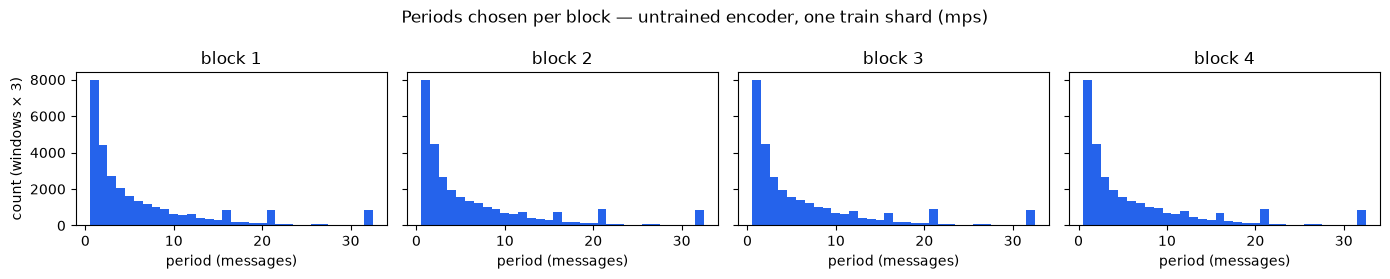

period 1 (window too short for a rhythm): 26.7% of all choices; most common real period: 2


In [11]:
diagnostic_model = TIMESNET.to(DEVICE)
with torch.no_grad():
    chosen = []
    for start in range(0, len(X_TRAIN), 512):
        diagnostic_model(X_TRAIN[start : start + 512].to(DEVICE), MASK_TRAIN[start : start + 512].to(DEVICE))
        chosen.append(diagnostic_model.periods_used())  # (blocks, b, k)
chosen = torch.cat(chosen, dim=1)  # (blocks, N, k)
fig, axes = plt.subplots(1, CONFIG.n_blocks, figsize=(14, 2.8), sharey=True)
for b, ax in enumerate(axes):
    values = chosen[b].flatten().numpy()
    ax.hist(values, bins=np.arange(0.5, values.max() + 1.5), color="#2563EB")
    ax.set_title(f"block {b + 1}")
    ax.set_xlabel("period (messages)")
axes[0].set_ylabel("count (windows × 3)")
plt.suptitle(f"Periods chosen per block — untrained encoder, one train shard ({DEVICE.type})")
plt.tight_layout()
plt.show()
p1_share = (chosen == 1).float().mean().item()
print(
    f"period 1 (window too short for a rhythm): {p1_share:.1%} of all choices; "
    f"most common real period: {int(torch.mode(chosen[chosen > 1]).values)}"
)

## Summary and what comes next

- **Built:** the TimesNet encoder, (x, mask) → (H, z), 2,301,312 parameters at d = 128, d_ff = 64 (D12), imported from
  `src/model/benign_gridsybil/timesnet/encoder.py`. The checks show that padding is ignored and that a window's
  output does not depend on its batch.
- **Not here:** training. Self-supervised pretraining (`python -m src.model.benign_gridsybil.timesnet.train`) adds the
  reconstruction head with a learned mask token, the P1–P3 heads on injected violations and the contrastive head
  (`heads.py`), and keeps only the encoder.
- **Few-shot fine-tuning and detection** then train on few labels and score windows from z (memory bank + kNN). Labels are used only
  there and in evaluation, never in pretraining.
